# Build Single Factor Model
## Setup 
### Import Python Packages 

In [1]:
# Import external packages
import pandas as pd
import numpy as np

import sys
import pickle
import warnings
from itertools import chain
# import random 
# import os

from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_percentage_error

from pygam import GAM, s, te, f, l, utils

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import LogLocator

import optuna
from optuna.visualization import matplotlib as optunampl

# Internal packages 
sys.path.append("../")
from src import utils
from src.gam import training, explain

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 260)
warnings.filterwarnings("ignore")

### Set Variables

In [30]:
# Fontsize for visualisation
tick_fontsize = 14
label_fontsize = 18
title_fontsize = 22

# Define utility columns
exposure = "Policies_Exposed"
target = "act_death_rate"
holdout = "holdout"
random_fold = "random_fold"

# Define actual and expected death count columns in the data
act_death = "Death_Count"
exp_death = "ExpDth_VBT2015_Cnt"
exp_death_mi = "ExpDth_VBT2015wMI_Cnt"

# Data
data_file = "export/Modelling_data (Filtered, Synchronised Attained_Age and Grouped by Selected Features).parquet"

# Define the modelling log that records key metrics in this notebook
modelling_log = f"output/02_model_note_single_factor_gam.xlsx"

# Define the name of the single factor GAM model
sf_gam_output = f"output/single_factor_gam.pkl"

# Define the name of the rating tables that defines the GAM model 
sf_rating_table_output = "output/single_factor_rating_tables.pkl"

## Create Modelling Dataframes
### Import Data

In [3]:
model_data = pd.read_parquet(data_file)
model_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate,exp_death_rate_mi
unique_id,,,,,,,,,,,,,,,,,,,,,
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487,1,0,10,0,2,0.000000,0.001502,0.001531
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595,1,0,11,0,3,0.000000,0.003048,0.003107
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922,1,0,6,0,1,0.001200,0.001125,0.001146
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057,1,0,4,0,5,0.004396,0.001501,0.001530
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154,1,0,2,0,5,0.000000,0.001765,0.001800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315,0,1,1,0,1,0.000000,0.125990,0.125990
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363,1,1,7,1,6,0.000000,0.028960,0.028228
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158,0,1,6,0,1,0.000000,0.019660,0.019945


In [4]:
###########################################################################
###########################################################################

# Define the list of numerical features
num_feat = [
    "Observation_Year", 
    "Duration", 
    "Attained_Age_Sync", 
    "Face_Amount_Band_ordinal"
]

# Define the list of categorical features
cat_feat = ["Sex_cat_level", "Smoker_Status_cat_level"]

###########################################################################
###########################################################################

# Define the full feature list 
all_feat = num_feat + cat_feat
print(all_feat)

['Observation_Year', 'Duration', 'Attained_Age_Sync', 'Face_Amount_Band_ordinal', 'Sex_cat_level', 'Smoker_Status_cat_level']


In [5]:
# Check there is no null value across the board 
model_data.isnull().sum()

Observation_Year            0
Sex                         0
Smoker_Status               0
Insurance_Plan              0
Duration                    0
Face_Amount_Band            0
Attained_Age_Sync           0
Amount_Exposed              0
Policies_Exposed            0
Death_Claim_Amount          0
Death_Count                 0
ExpDth_VBT2015_Cnt          0
ExpDth_VBT2015wMI_Cnt       0
Sex_cat_level               0
Smoker_Status_cat_level     0
Face_Amount_Band_ordinal    0
holdout                     0
random_fold                 0
act_death_rate              0
exp_death_rate              0
exp_death_rate_mi           0
dtype: int64

### Define Required Dataframes

In [6]:
# Define the training and holdout dataframes
X_train = model_data.loc[model_data[holdout] == 0, all_feat]
y_train = model_data.loc[model_data[holdout] == 0, target]
w_train = model_data.loc[model_data[holdout] == 0, exposure]

X_test = model_data.loc[model_data[holdout] == 1, all_feat]
y_test = model_data.loc[model_data[holdout] == 1, target]
w_test = model_data.loc[model_data[holdout] == 1, exposure]

# Define the cross-validation folds required for hyperparameter tuning
random_fold_values = model_data.loc[model_data[holdout] == 0, random_fold].values

# Define a list of tuples, each first element contains indices for the training fold and each second element contains indices for the holdout
folds = []
df_ = pd.DataFrame(
    zip(range(len(random_fold_values)), random_fold_values),
    columns=["row_index", random_fold],
)

for i in range(max(random_fold_values)):
    index_train = df_[df_[random_fold] != i + 1]["row_index"].to_list()
    index_valid = df_[df_[random_fold] == i + 1]["row_index"].to_list()
    folds.append((index_train, index_valid))

valid_folds = [k[1] for k in folds]
check = np.sort(np.array(list(chain(*valid_folds)))) == np.arange(len(X_train))

assert check.sum() == len(
    X_train
), "Not all the rows in the training data are included in the data folds."

In [7]:
# Create a term string for GAM training
term_string, num_feat_map, cat_feat_map, _ = training.create_term_structure(
    num_feat,
    cat_feat,
    X_train,
)
print(term_string)

s(0, lam=lam_num, n_splines=n_splines)+ s(1, lam=lam_num, n_splines=n_splines)+ s(2, lam=lam_num, n_splines=n_splines)+ s(3, lam=lam_num, n_splines=n_splines) + f(4, lam=lam_cat) + f(5, lam=lam_cat)


In [8]:
# Create training and validation sets for each permutation of the random folds
X_train_cv = {}
X_valid_cv = {}
w_train_cv = {}
w_valid_cv = {}
y_train_cv = {}
y_valid_cv = {}

for i, (train_index, valid_index) in enumerate(folds):
    X_train_cv[i] = X_train.iloc[train_index]
    X_valid_cv[i] = X_train.iloc[valid_index]
    w_train_cv[i] = w_train.iloc[train_index]
    w_valid_cv[i] = w_train.iloc[valid_index]
    y_train_cv[i] = y_train.iloc[train_index]
    y_valid_cv[i] = y_train.iloc[valid_index]

## Hyperparameter Tuning

In [9]:
# Create study
study = optuna.create_study(direction="minimize")

# Define objective
objective = training.OptunaGamObjectiveCV(
    term_string,
    5,
    (8, 15), # Need to experiment with the range 
    (1, 1e3, True), 
    (1, 1e3, True),
    X_train_cv, 
    X_valid_cv, 
    y_train_cv, 
    y_valid_cv,
    w_train_cv, 
    w_valid_cv, 
)

[I 2026-01-11 16:24:41,115] A new study created in memory with name: no-name-bd88fc73-9a78-4de9-b7e5-133e660b76b2


In [36]:
###########################################################################
###########################################################################

n_trials = 30

###########################################################################
###########################################################################

# Do study
study.optimize(objective, n_trials=n_trials)

[I 2026-01-04 18:58:05,375] Trial 0 finished with value: 223619.45423307526 and parameters: {'n_splines': 12, 'lam_num': 7.6752197791322905, 'lam_cat': 4.7453543598703405, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 223619.45423307526.
[I 2026-01-04 18:59:37,946] Trial 1 finished with value: 224081.85141052012 and parameters: {'n_splines': 10, 'lam_num': 202.75384803941813, 'lam_cat': 263.1669134861268, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 223619.45423307526.
[I 2026-01-04 19:00:58,145] Trial 2 finished with value: 224723.52942037012 and parameters: {'n_splines': 9, 'lam_num': 529.3763902079502, 'lam_cat': 25.21801408287633, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 223619.45423307526.
[I 2026-01-04 19:02:16,375] Trial 3 finished with value: 223923.66432414664 and parameters: {'n_splines': 8, 'lam_num': 2.2517996706473515, 'la

In [37]:
# Print best trial
best_trial_number = study.best_trial.number
best_trial_value = study.best_trial.value
print(f"Best trial: {best_trial_number} with value {best_trial_value}\n{'*'*80}")

# Print out the best parameters
best_hyperparams = study.best_params
print(best_hyperparams)

Best trial: 14 with value 223568.18859626795
********************************************************************************
{'n_splines': 14, 'lam_num': 1.324203545099112, 'lam_cat': 78.41807431306853, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}


In [38]:
# Save the tuning progress
with pd.ExcelWriter(
    f"{modelling_log}", engine="openpyxl"
) as writer:
    study.trials_dataframe().sort_values("value").to_excel(
        writer, sheet_name="Single_Factor_Tune", index=False
    )

<Axes: title={'center': 'Empirical Distribution Function Plot'}, xlabel='Objective Value', ylabel='Cumulative Probability'>

<Figure size 640x480 with 0 Axes>

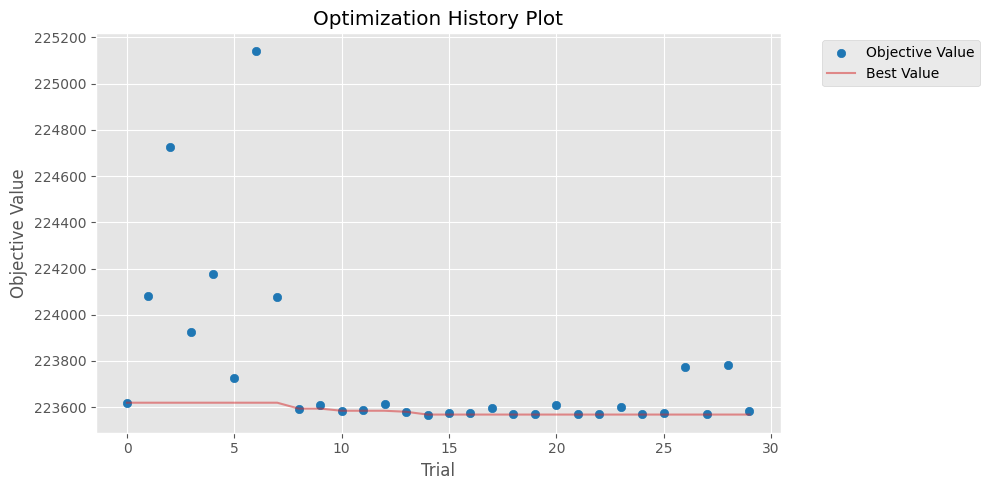

<Figure size 1000x500 with 0 Axes>

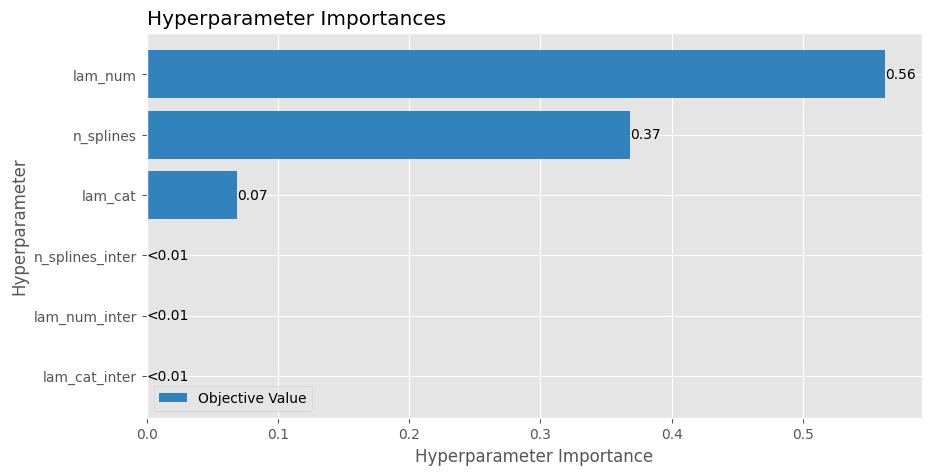

<Figure size 1000x500 with 0 Axes>

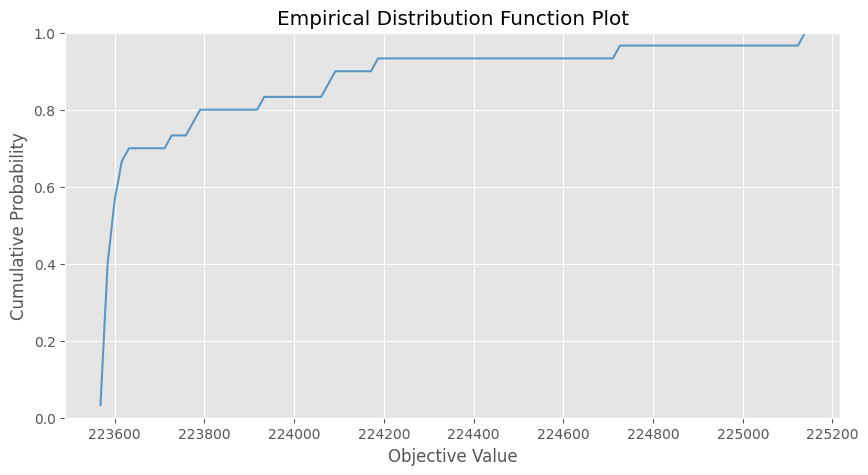

In [39]:
plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_optimization_history(study)

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_param_importances(study)

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_edf(study)

array([<Axes: xlabel='lam_cat', ylabel='Objective Value'>,
       <Axes: xlabel='lam_num'>, <Axes: xlabel='n_splines'>], dtype=object)

<Figure size 1000x500 with 0 Axes>

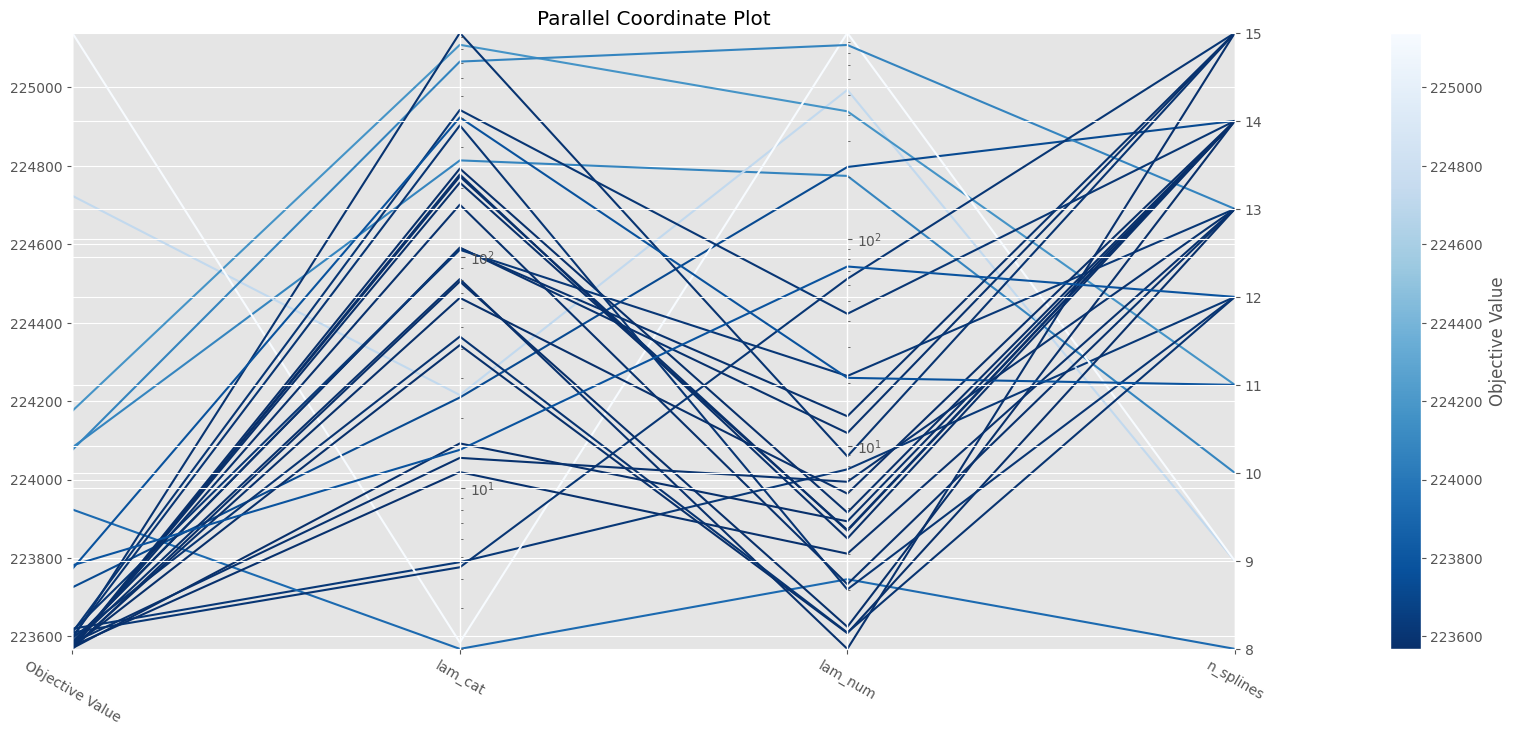

<Figure size 2000x800 with 0 Axes>

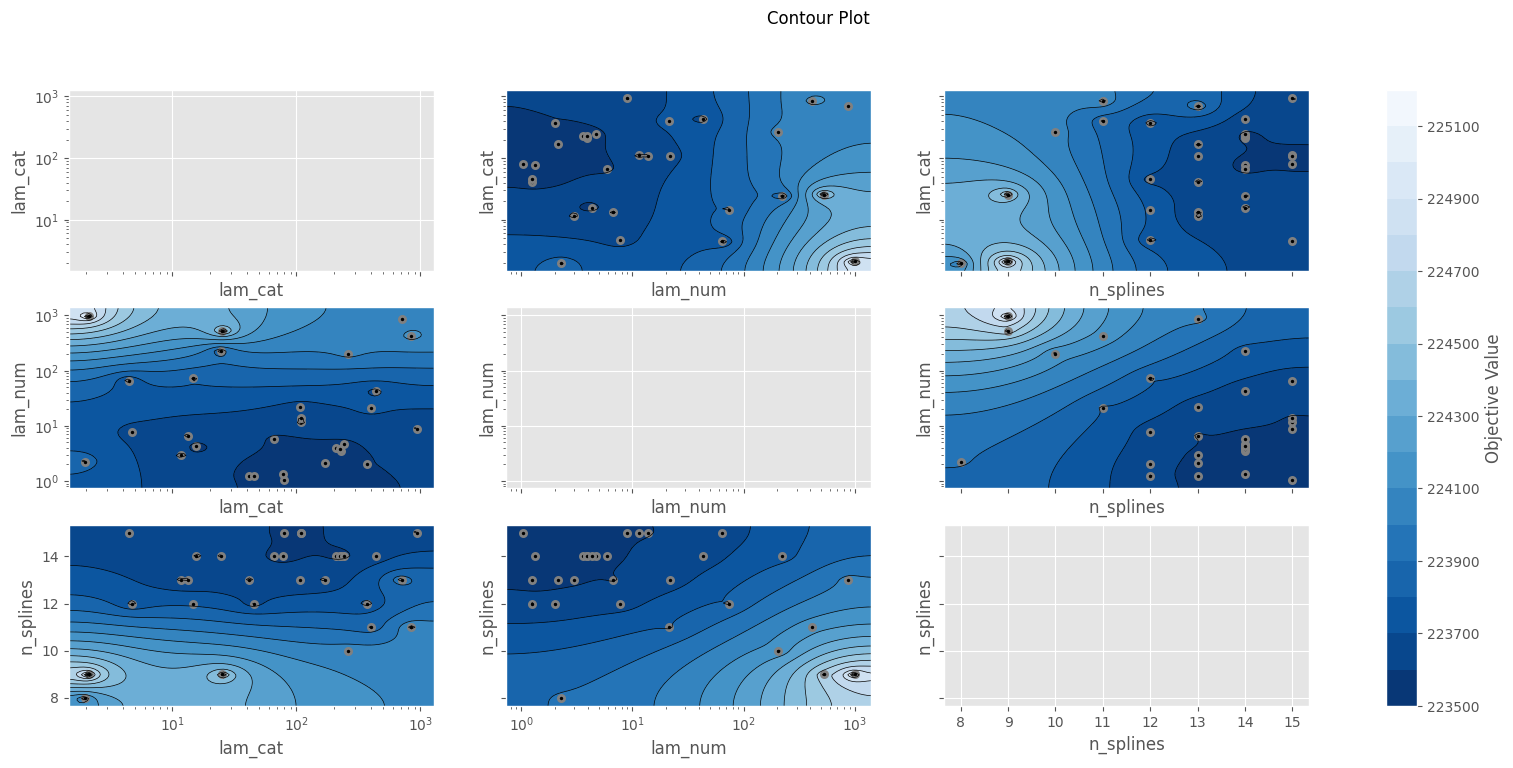

<Figure size 2000x800 with 0 Axes>

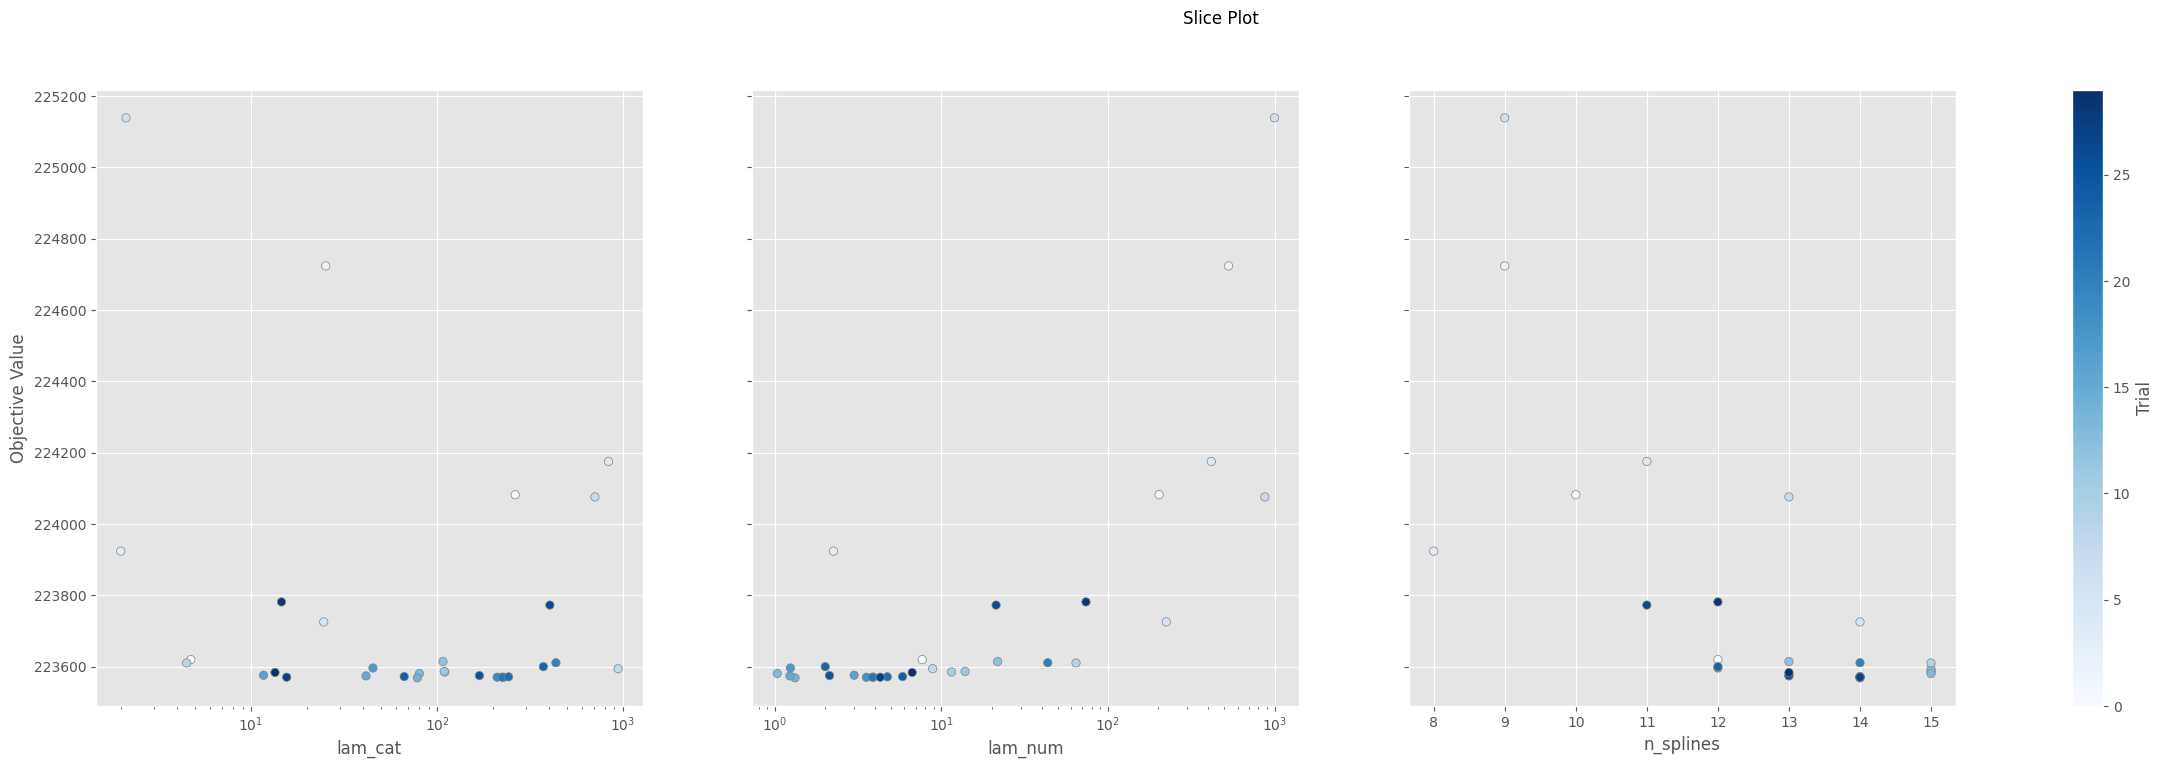

In [40]:
param_importance = optuna.importance.get_param_importances(study)

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_parallel_coordinate(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_contour(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_slice(study, params=list(param_importance)[:3])

## Train Single Factor GAM Model

In [10]:
study_df = pd.read_excel(f"{modelling_log}", "Single_Factor_Tune")
best_params = study_df.sort_values("value").filter(regex="params_").iloc[0].to_dict()
best_params = {k.replace("params_", ""): v for k, v in best_params.items()}

n_splines = int(best_params["n_splines"])
lam_num = best_params["lam_num"]
lam_cat = best_params["lam_cat"]

print(f"n_splines: {n_splines}")
print(f"lam_num: {lam_num}")
print(f"lam_cat: {lam_cat}")

n_splines: 14
lam_num: 1.324203545099112
lam_cat: 78.41807431306853


In [42]:
# Fit the GAM model
gam_model = GAM(
    eval(term_string),
    distribution="poisson",
    link="log",
).fit(X_train, y_train, weights=w_train)

gam_model.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     42.5046
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                       408239 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.5476
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.9219
Feature Function                  Lam

In [ ]:
# Save the GAM model as a pickle file
with open(sf_gam_output, "wb") as file:
    pickle.dump(gam_model, file)

### Derive Relativities

In [11]:
# Re-load the GAM model
with open(sf_gam_output, "rb") as file:
    gam_model = pickle.load(file)

gam_model.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     42.5046
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                       408239 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.5476
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.9219
Feature Function                  Lam

In [12]:
# Initialise an empty list to save the multiplier applied to the intercept
intercept_adj_list = []
# Get the intercept of GAM
intercept = np.exp(gam_model.coef_[-1])
print(f"GAM Intercept: {intercept:.2%}")

# Define a list of all variables used in the model
all_feat = list(num_feat_map.values()) + list(cat_feat_map.values())
number_factors = len(all_feat)

GAM Intercept: 1.49%


#### Numerical Variables

In [13]:
# Initilise an empty dictionary for numerical variables
num_rel_dict = {}

for k, v in num_feat_map.items():
    
    # Get the unique levels associated with a numerical variable
    index = np.sort(X_train[v].unique())

    assert (
        np.unique(np.diff(index))[0] == 1 and len(np.unique(np.diff(index))) == 1
    ), "There are probably missing levels in the numerical range. Please check!!"

    # Initialise a 0-array as an input to calculate partial dependency
    t = np.zeros((len(index), number_factors))

    # Get the column index of the numerical variable
    z = X_train.columns.tolist().index(v)

    # Populate the column related to the variable for which we seek partial dependency
    t[:, z] = index

    # Need to use an internal function from PyGAM to get the partial dependence
    modelmat = gam_model.terms.build_columns(t, term=k)
    partial_dependence = np.exp(gam_model._linear_predictor(modelmat=modelmat, term=k))

    # Concatenate the feature values and PDs
    prediction = pd.DataFrame(zip(index, partial_dependence), columns=[v, "pred"])

    # Adjust the PDs such that its weighted average level is 1
    prediction["relativity"] = prediction["pred"].copy()
    prediction = prediction.join(
        X_train.join(w_train).groupby(v)[[exposure]].sum(), on=v
    )
    prediction["rel_weight"] = prediction["relativity"] * prediction[exposure]
    avg_rel = prediction["rel_weight"].sum() / prediction[exposure].sum()
    prediction["relativity"] /= avg_rel

    # Record the multiplier (this needs to be applied to intercept)
    intercept_adj_list.append(avg_rel)
    num_rel_dict[v] = prediction[[v, "relativity", exposure]]

#### Categorical Variables

In [14]:
###########################################################################
###########################################################################

# Define the directory for the categorical mapping spreadsheet
cat_map_table = "export/SOA Categorical Mapping.xlsx"
# Get the mapping tables in the form of a dictionary
cat_map_dict = pd.read_excel(cat_map_table, sheet_name=None)

###########################################################################
###########################################################################

# Initilise an empty dictionary for numerical variables
cat_rel_dict = {}

for k, v in cat_feat_map.items(): 
    
    # Define the clean variable name
    v_clean = v.replace("_cat_level", "")

    # Get the unique levels associated with a categorical variable
    index = np.sort(X_train[v].unique())

    assert (
        np.unique(np.diff(index))[0] == 1 and len(np.unique(np.diff(index))) == 1
    ), "There are probably missing levels in the categorical range. Please check!!"

    # Initialise a 0-array as an input to calculate partial dependency
    t = np.zeros((len(index), number_factors))

    # Get the column index of the numerical variable
    z = X_train.columns.tolist().index(v)

    # Populate the column related to the variable for which we seek partial dependency
    t[:, z] = index

    # Need to use an internal function from PyGAM to get the partial dependence
    modelmat = gam_model.terms.build_columns(t, term=k)
    partial_dependence = np.exp(gam_model._linear_predictor(modelmat=modelmat, term=k))

    # Concatenate the feature values and PDs
    prediction = pd.DataFrame(zip(index, partial_dependence), columns=[v, "pred"])

    # Adjust the PDs such that its weighted average level is 1
    prediction["relativity"] = prediction["pred"].copy()
    prediction = prediction.join(X_train.join(w_train).groupby(v)[[exposure]].sum(), on=v)
    prediction["rel_weight"] = prediction["relativity"] * prediction[exposure]
    avg_rel = prediction["rel_weight"].sum() / prediction[exposure].sum()
    prediction["relativity"] /= avg_rel

    # Get the categorical levels
    table = cat_map_dict[v_clean]
    prediction[v_clean] = prediction[v].map(
        table.set_index("Integer_Value")["Categorical_Level"].to_dict()
    )

    # Record the multiplier (this needs to be applied to intercept)
    intercept_adj_list.append(avg_rel)
    cat_rel_dict[v] = prediction[[v, v_clean, "relativity", exposure]]

#### Adjust Intercept Term

In [15]:
assert len(intercept_adj_list) == len(
    all_feat
), "# intercept multipliers is not equal to # terms in GAM. Please check!!"

# Perform the adjustment
intercept_final = intercept * np.prod(intercept_adj_list) 

utils.pretty_print("Intercept Values")
print(f"{'Original':<10}: {intercept:,.5%}")
print(f"{'Adjusted':<10}: {intercept_final:,.5%}")

----------------
Intercept Values
----------------
Original  : 1.49048%
Adjusted  : 0.16226%


#### Export Intercept and Relativities

In [317]:
# Define the output
rating_tables = (intercept_final, num_rel_dict, cat_rel_dict)
# Save
with open(sf_rating_table_output, "wb") as file: 
    pickle.dump(rating_tables, file) 

#### Control Testing

In [16]:
# Re-load the rating table outputs 
with open(sf_rating_table_output, "rb") as file: 
    intercept_final, num_rel_dict, cat_rel_dict = pickle.load(file)

# Define a dataframe that contains predictions, target and weight
ypred_test = gam_model.predict(X_test)

ypred_test_df = pd.DataFrame(
    ypred_test, columns=["ypred_death_rate"], index=X_test.index
)
ypred_test_df = (
    ypred_test_df.join(y_test)
    .join(w_test)
    .join(
        model_data[
            [
                "Death_Count",
                "ExpDth_VBT2015_Cnt",
                "ExpDth_VBT2015wMI_Cnt",
                "exp_death_rate",
                "exp_death_rate_mi",
            ]
        ]
    )
)
ypred_test_df["ypred_death_count"] = (
    ypred_test_df["ypred_death_rate"] * ypred_test_df[exposure]
)
ypred_test_df

,ypred_death_rate,act_death_rate,Policies_Exposed,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,exp_death_rate,exp_death_rate_mi,ypred_death_count
unique_id,,,,,,,,,
24,0.000409,0.000466,4290.800011,2.0,2.459256,2.424128,0.000573,0.000565,1.752993
25,0.000508,0.000654,3059.967118,2.0,1.548564,1.526444,0.000506,0.000499,1.554077
26,0.001956,0.001662,4212.210949,7.0,7.150017,6.969210,0.001697,0.001655,8.239771
27,0.004686,0.002416,413.895889,1.0,1.253551,1.221852,0.003029,0.002952,1.939622
28,0.002562,0.000000,443.816434,0.0,1.369450,1.334820,0.003086,0.003008,1.136914
...,...,...,...,...,...,...,...,...,...
575740,0.093225,0.000000,0.221918,0.0,0.010816,0.010611,0.048740,0.047814,0.020688
575744,0.016529,0.000000,0.624658,0.0,0.013411,0.013220,0.021470,0.021163,0.010325
575746,0.007611,0.000000,0.369863,0.0,0.005533,0.005454,0.014960,0.014746,0.002815


In [17]:
###############################################################
###############################################################

# Define the number of decimal places to round the predictions
rounding_num = 7

###############################################################
###############################################################

# Test on the training ata
ypred_train = gam_model.predict(X_train)

# Define a procedure to score a dataset using the relativities extracted
X_train_rel = X_train.copy()
rel_list = []

for v, r in num_rel_dict.items():
    X_train_rel[v + "_rel"] = X_train_rel[v].map(r.set_index(v)["relativity"].to_dict())
    rel_list.append(v + "_rel")

for v, r in cat_rel_dict.items():
    X_train_rel[v.replace("_cat_level", "") + "_rel"] = X_train_rel[v].map(
        r.set_index(v)["relativity"].to_dict()
    )
    rel_list.append(v.replace("_cat_level", "") + "_rel")

# Check there are no null values
assert (
    X_train_rel.isnull().sum().sum() == 0
), "There are NA values in relativities calculated. Please check!!"

ypred_train_df = pd.DataFrame(
    ypred_train, columns=["ypred_death_rate"], index=X_train.index
)

ypred_train_df["ypred_death_rate_rel"] = (
    X_train_rel[rel_list].prod(axis=1) * intercept_final
)

check_df = ypred_train_df[
    ypred_train_df["ypred_death_rate"].round(rounding_num)
    != ypred_train_df["ypred_death_rate_rel"].round(rounding_num)
]

# Check if there is any diff between the predictions from model and the predictions from rating tables
assert (
    len(check_df) == 0
), "There are differences detected between the model predictions and the predictions from rating tables. Please check!!"

In [18]:
# Need an augmented X_test as Observation_Year and Duration need to be set as the max observaed values in the training data
X_test2 = X_test.copy()
X_test2["Observation_Year"] = np.where(
    X_test["Observation_Year"] > X_train["Observation_Year"].max(),
    X_train["Observation_Year"].max(),
    X_test["Observation_Year"],
)
X_test2["Duration"] = np.where(
    X_test["Duration"] > X_train["Duration"].max(),
    X_train["Duration"].max(),
    X_test["Duration"],
)
X_test2

,Observation_Year,Duration,Attained_Age_Sync,Face_Amount_Band_ordinal,Sex_cat_level,Smoker_Status_cat_level
unique_id,,,,,,
24,2017,13,39,6,0,0
25,2017,10,40,5,0,0
26,2017,20,50,5,1,0
27,2017,25,55,4,1,0
28,2017,27,55,6,1,0
...,...,...,...,...,...,...
575740,2017,37,79,2,0,1
575744,2017,19,78,10,0,0
575746,2017,34,65,8,0,1


In [19]:
# Define a procedure to score a dataset using the relativities extracted
X_test2_rel = X_test2.copy()
rel_list = []

for v, r in num_rel_dict.items():
    X_test2_rel[v + "_rel"] = X_test2_rel[v].map(r.set_index(v)["relativity"].to_dict())
    rel_list.append(v + "_rel")

for v, r in cat_rel_dict.items():
    X_test2_rel[v.replace("_cat_level", "") + "_rel"] = X_test2_rel[v].map(
        r.set_index(v)["relativity"].to_dict()
    )
    rel_list.append(v.replace("_cat_level", "") + "_rel")

# Check there is no null values
X_test2_rel.isnull().sum()

Observation_Year                0
Duration                        0
Attained_Age_Sync               0
Face_Amount_Band_ordinal        0
Sex_cat_level                   0
Smoker_Status_cat_level         0
Observation_Year_rel            0
Duration_rel                    0
Attained_Age_Sync_rel           0
Face_Amount_Band_ordinal_rel    0
Sex_rel                         0
Smoker_Status_rel               0
dtype: int64

In [20]:
ypred_test_df["ypred_death_rate_rel"] = (
    X_test2_rel[rel_list].prod(axis=1) * intercept_final
)
ypred_test_df["ypred_death_count_rel"] = (
    ypred_test_df["ypred_death_rate_rel"] * ypred_test_df[exposure]
)
ypred_test_df["ratio_diff"] = (
    ypred_test_df["ypred_death_count_rel"] / ypred_test_df["ypred_death_count"]
)
ypred_test_df

,ypred_death_rate,act_death_rate,Policies_Exposed,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,exp_death_rate,exp_death_rate_mi,ypred_death_count,ypred_death_rate_rel,ypred_death_count_rel,ratio_diff
unique_id,,,,,,,,,,,,
24,0.000409,0.000466,4290.800011,2.0,2.459256,2.424128,0.000573,0.000565,1.752993,0.000416,1.785105,1.018319
25,0.000508,0.000654,3059.967118,2.0,1.548564,1.526444,0.000506,0.000499,1.554077,0.000517,1.582546,1.018319
26,0.001956,0.001662,4212.210949,7.0,7.150017,6.969210,0.001697,0.001655,8.239771,0.002028,8.544420,1.036973
27,0.004686,0.002416,413.895889,1.0,1.253551,1.221852,0.003029,0.002952,1.939622,0.004860,2.011335,1.036973
28,0.002562,0.000000,443.816434,0.0,1.369450,1.334820,0.003086,0.003008,1.136914,0.002656,1.178949,1.036973
...,...,...,...,...,...,...,...,...,...,...,...,...
575740,0.093225,0.000000,0.221918,0.0,0.010816,0.010611,0.048740,0.047814,0.020688,0.096671,0.021453,1.036973
575744,0.016529,0.000000,0.624658,0.0,0.013411,0.013220,0.021470,0.021163,0.010325,0.016832,0.010514,1.018319
575746,0.007611,0.000000,0.369863,0.0,0.005533,0.005454,0.014960,0.014746,0.002815,0.007751,0.002867,1.018319


We can see that the levels of differences are caused by observation year and duration being outside of the training range. 

In [21]:
X_test_invest = X_test[["Observation_Year", "Duration"]].join(
    ypred_test_df["ratio_diff"].round(rounding_num)
)
X_test_invest["Duration"] = np.where(
    X_test["Duration"] <= X_train["Duration"].max(), 0, X_test["Duration"]
)
X_test_invest_unique = X_test_invest.drop_duplicates()
X_test_invest_unique.set_index(["Observation_Year", "Duration"], inplace=True)
X_test_invest_unique.sort_values("ratio_diff", inplace=True)
X_test_invest_unique

ratio_diff
Observation_Year Duration            
2018             0           1.018319
2019             0           1.036973
2018             39          1.041437
2019             39          1.060515
                 40          1.084592

### Holdout Assessment

In [22]:
# Poisson Deviance
gam_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ypred_death_count"],
)
rel_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ypred_death_count_rel"],
)
exp_mi_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ExpDth_VBT2015wMI_Cnt"],
)

exp_dev = utils.total_poisson_dev(
    y=ypred_test_df["Death_Count"],
    y_pred=ypred_test_df["ExpDth_VBT2015_Cnt"],
)

utils.pretty_print("Total Poisson Deviance")
print(f"{'GAM Model':<25}: {gam_dev:,.0f}")
print(f"{'GAM Rel':<25}: {rel_dev:,.0f}")
print(f"{'SOA Expected (with MI)':<25}: {exp_mi_dev:,.0f}")
print(f"{'SOA Expected':<25}: {exp_dev:,.0f}")

----------------------
Total Poisson Deviance
----------------------
GAM Model                : 101,365
GAM Rel                  : 101,690
SOA Expected (with MI)   : 111,036
SOA Expected             : 110,776


In [90]:
corr, _ = pearsonr(
    ypred_test_df["exp_death_rate_mi"], ypred_test_df["ypred_death_rate_rel"]
)
print(f"Correlation between GAM Rel and SOA Expected Death Rate: {corr:.2%}")

Correlation between GAM Rel and SOA Expected Death Rate: 90.50%


In [23]:
################################################################
################################################################

# Define the list of new to current model prediction column names
predict = ["ypred_death_count_rel", "ExpDth_VBT2015wMI_Cnt"]

################################################################
################################################################

d = utils.DoubleLift(
    ypred_test_df, predict, "Death_Count", exposure, [0.01, 0.95], approx_num_band=25
)

mape_gam = mean_absolute_percentage_error(
    d.double_lift_table["Death_Count"],
    d.double_lift_table[predict[0]],
    sample_weight=d.double_lift_table[exposure],
)
mape_expected = mean_absolute_percentage_error(
    d.double_lift_table["Death_Count"],
    d.double_lift_table[predict[1]],
    sample_weight=d.double_lift_table[exposure],
)
print(f"{'MAPE - GAM Rel':<30}: {mape_gam:.2%}")
print(f"{'MAPE - SOA Expected (with MI)':<30}: {mape_expected:.2%}")

d.double_lift_table

MAPE - GAM Rel                : 4.28%
MAPE - SOA Expected (with MI) : 23.26%


,ratio_band,Death_Count,ypred_death_count_rel,ExpDth_VBT2015wMI_Cnt,Policies_Exposed
band,,,,,
1,<= 0.6,0.002386,0.002032,0.003567,9.869852e+05
2,"(0.6, 0.7]",0.001795,0.001683,0.002560,7.040664e+06
3,"(0.7, 0.8]",0.001530,0.001460,0.001966,1.018383e+07
4,"(0.8, 0.9]",0.002061,0.002030,0.002373,7.238422e+06
5,"(0.9, 1.0]",0.002501,0.002433,0.002571,7.084363e+06
6,"(1.0, 1.1]",0.001818,0.001790,0.001717,3.970489e+06
7,"(1.1, 1.2]",0.001763,0.001710,0.001491,2.186953e+06
8,"(1.2, 1.3]",0.002745,0.002831,0.002256,1.399566e+06
9,"(1.3, 1.4]",0.004143,0.004145,0.003067,1.298740e+06


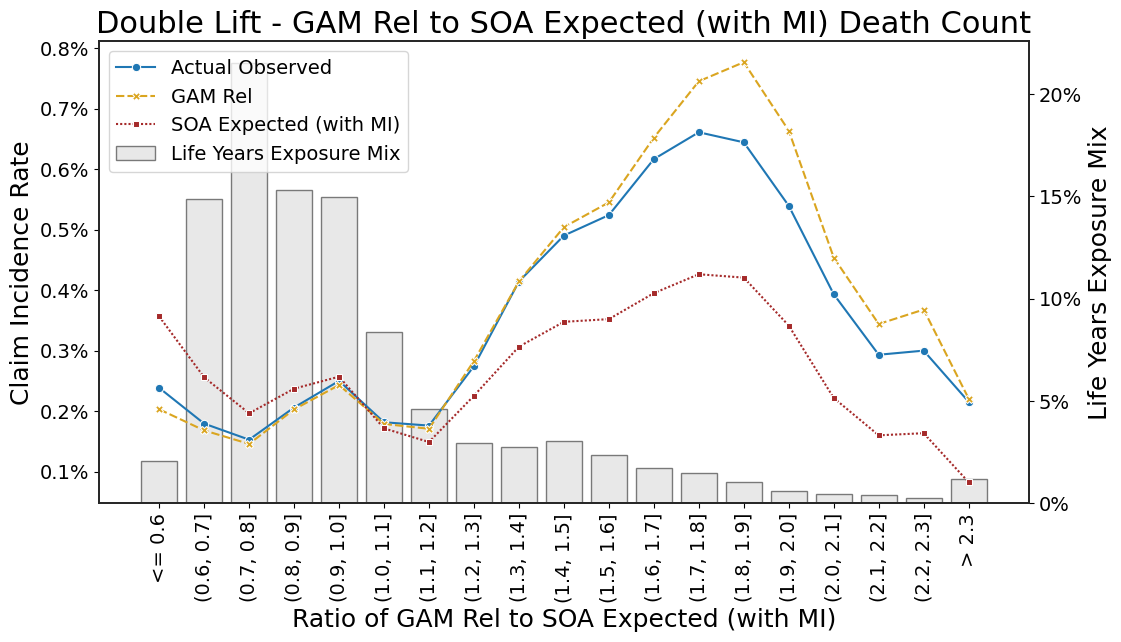

In [24]:
###########################################################################
###########################################################################

param_dict = {
    "title": "Double Lift - GAM Rel to SOA Expected (with MI) Death Count", 
    "leftylabel": "Claim Incidence Rate", 
    "rightylabel": "Life Years Exposure Mix",
    "target_legend": "Actual Observed", 
    "new_model_legend": "GAM Rel",
    "baseline_legend": "SOA Expected (with MI)",
    "palette": ["tab:blue", "#DAA520", "#A52A2A"]
}

###########################################################################
###########################################################################

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

fig, ax = plt.subplots(figsize=(12, 6))

d.plot_double_lift(ax=ax, **param_dict)

## Model Explanation 
### Factor Strength

In [25]:
single_fact_df, _ = explain.factor_strength(num_rel_dict, cat_rel_dict, weight=exposure)
single_fact_df

,feature,feature_type,factor_strength
0,Attained_Age_Sync,numerical,1.333323
1,Smoker_Status,categorical,0.321954
2,Face_Amount_Band_ordinal,numerical,0.294150
3,Duration,numerical,0.246271
4,Sex,categorical,0.164096
5,Observation_Year,numerical,0.017441


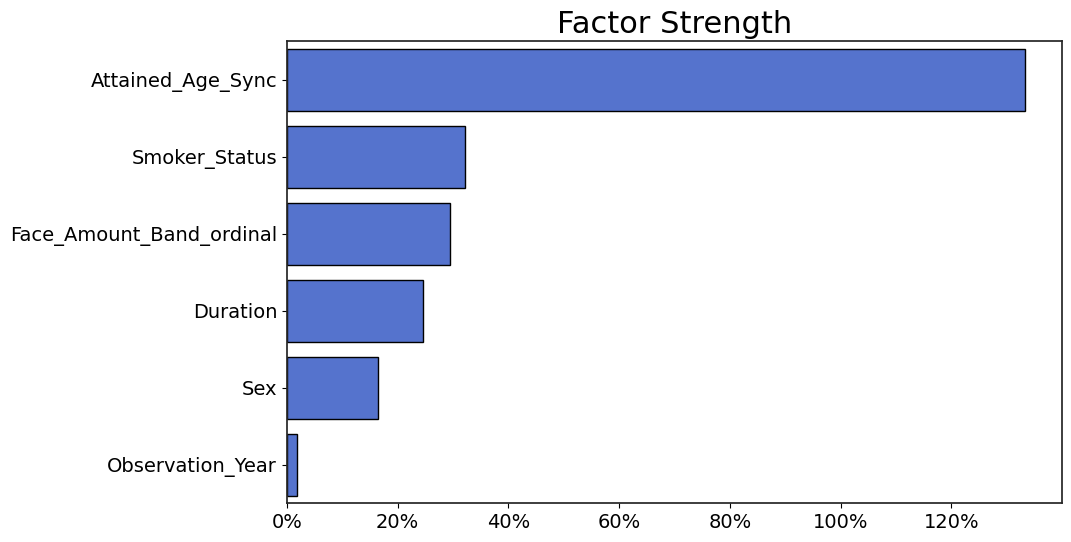

In [26]:
fig, ax = plt.subplots(1, figsize=(10, 6))
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"]  = 1.25

# Plot data
sns.barplot(
    x="factor_strength",
    y="feature",
    data=single_fact_df,
    ax=ax,
    color="royalblue",
    edgecolor="black",
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
ax.set_title(
    f"Factor Strength", fontsize=title_fontsize
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)
ax.set_facecolor("white")

### Single Factor Trends

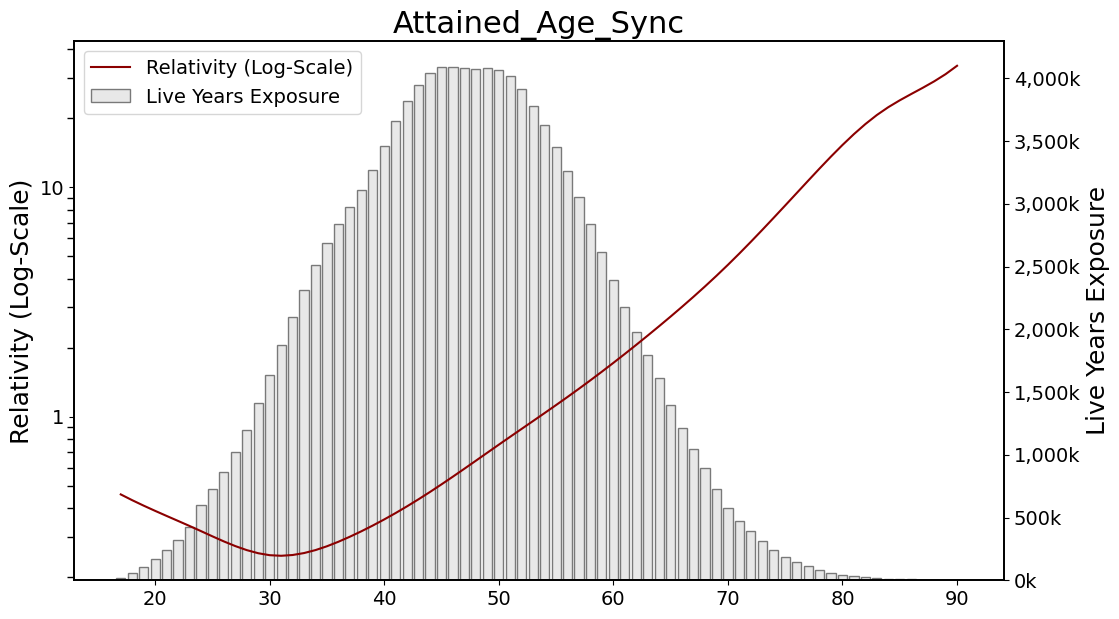

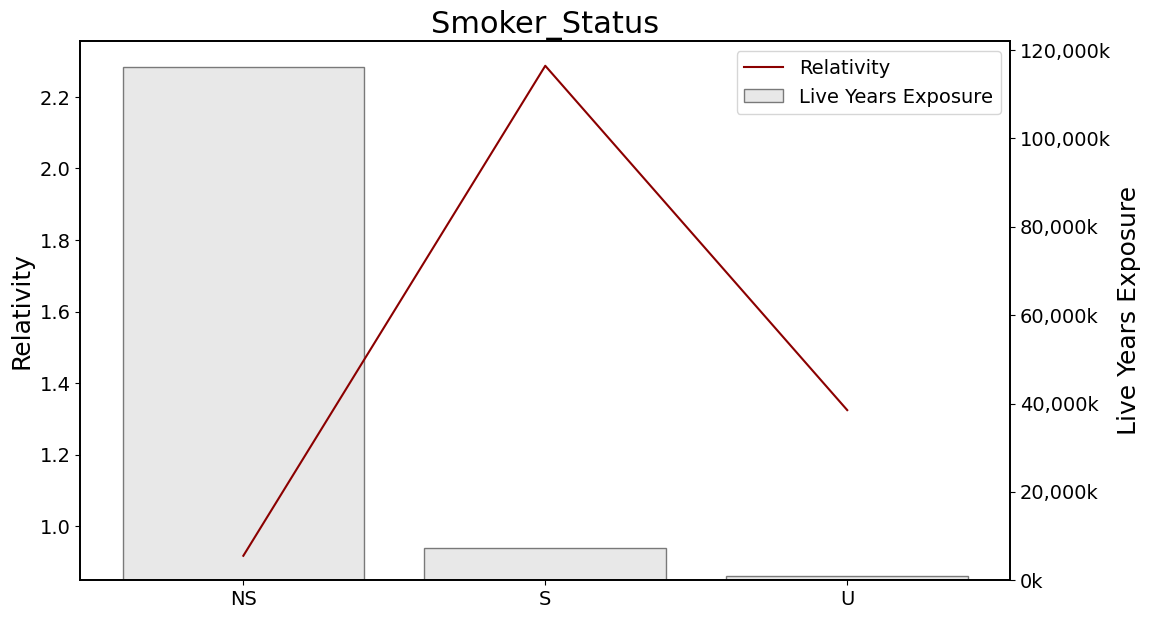

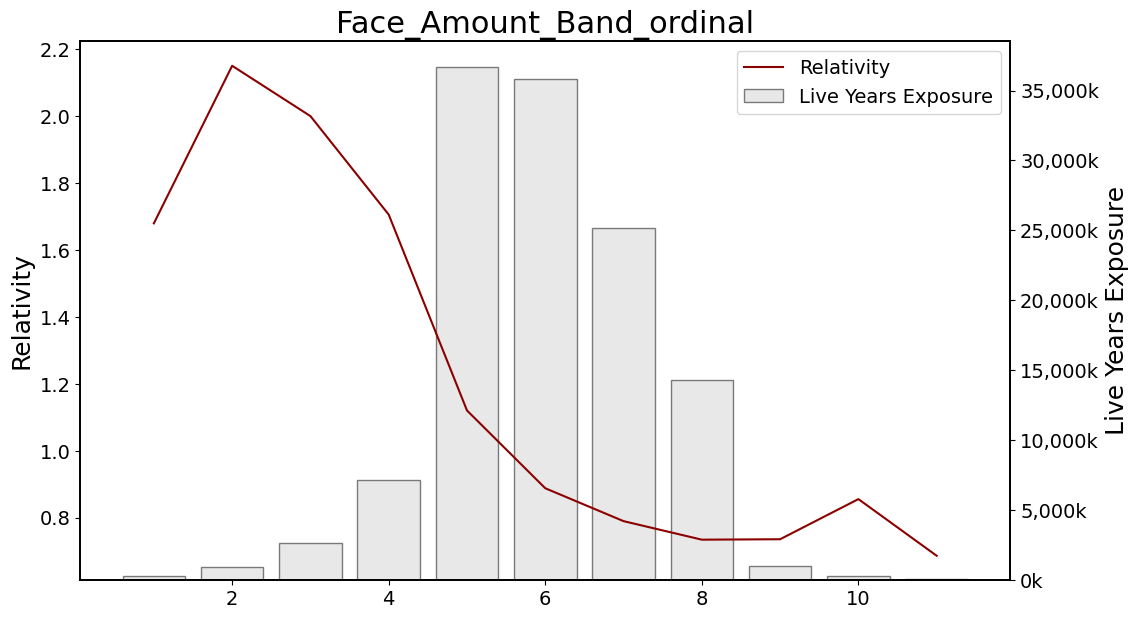

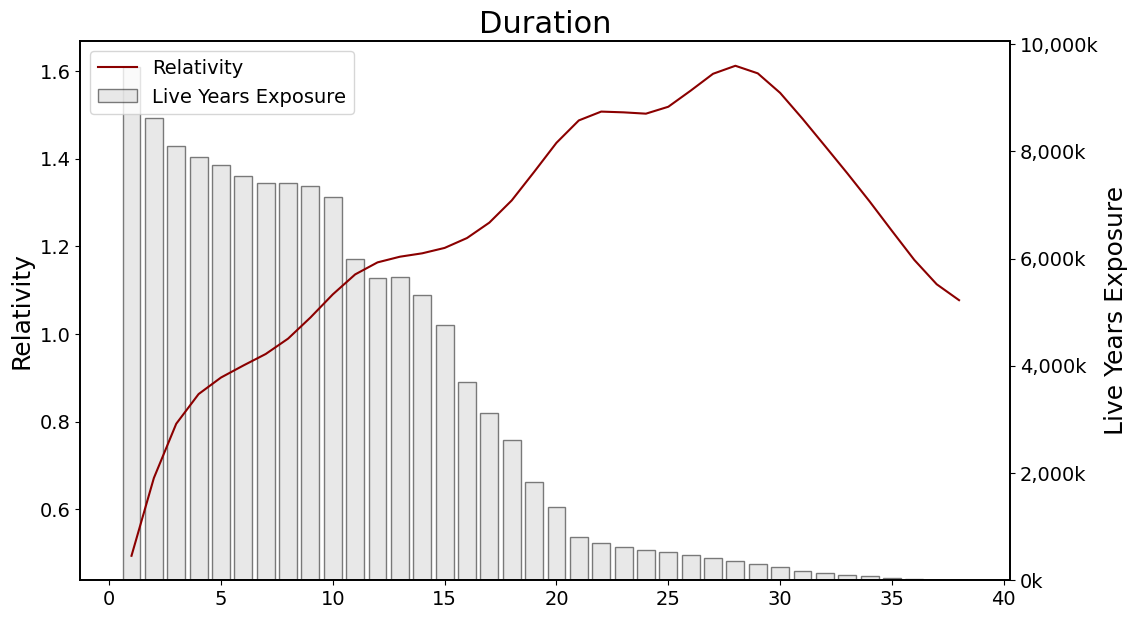

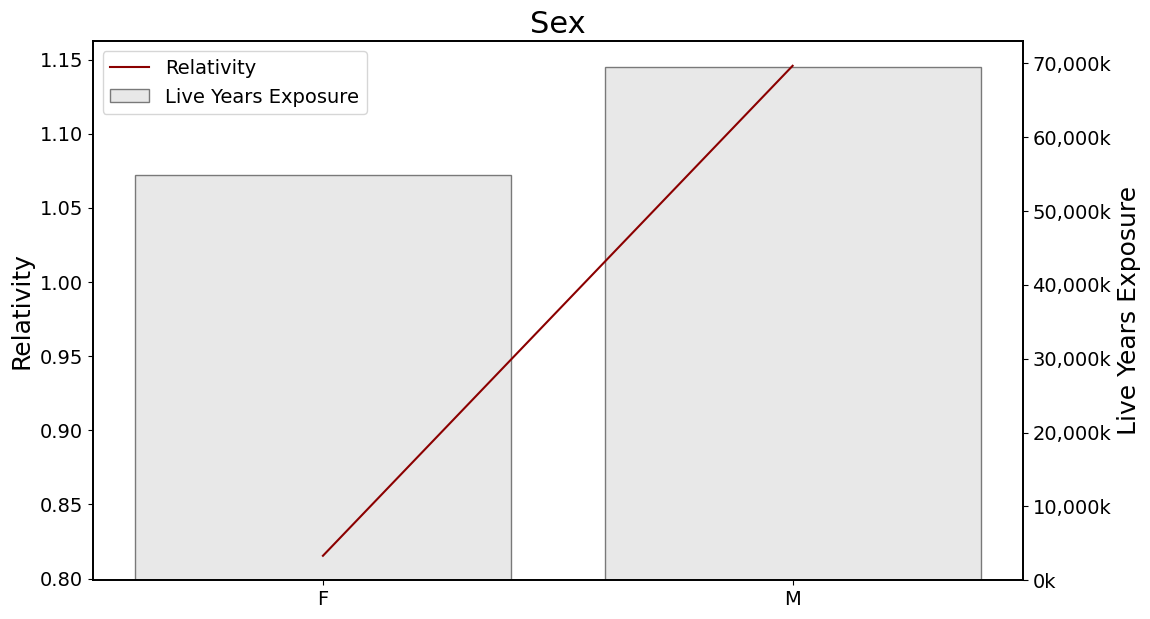

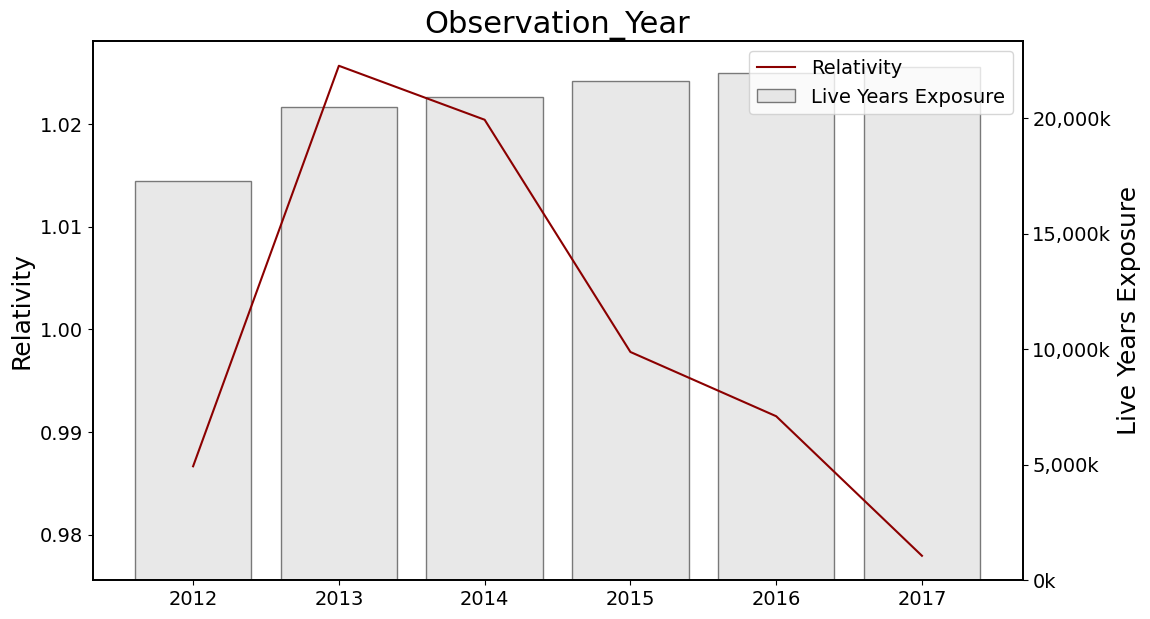

In [27]:
###################################################################
###################################################################

# Define the age variable
age_var = "Attained_Age_Sync"
rightylabel = "Live Years Exposure"

###################################################################
###################################################################

for v in single_fact_df["feature"]:

    # Get the relativity table
    rel_table = (
        num_rel_dict[v] if v in num_rel_dict.keys() else cat_rel_dict[v + "_cat_level"]
    )
    rel_table = rel_table.set_index(v)
    # Start plotting
    fig, ax = plt.subplots(1, figsize=(12, 7))
    leftylabel = "Relativity (Log-Scale)" if v == age_var else "Relativity"

    sns.lineplot(data=rel_table["relativity"], ax=ax, color="darkred", label=leftylabel)

    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
    ax.set_xlabel("")
    ax.set_ylabel(leftylabel, fontsize=label_fontsize)
    ax.set_title(v, fontsize=title_fontsize)

    if v == age_var:
        ax.set_yscale("log")

        # Set specific tick locations
        ax.yaxis.set_major_locator(mtick.FixedLocator([1, 10]))

        # Format labels
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: "{:g}".format(y)))

        # Add minor ticks for gridlines
        ax.yaxis.set_minor_locator(
            LogLocator(base=10, subs=np.arange(2, 10), numticks=10)
        )
        ax.tick_params(axis="y", which="minor", length=5, width=1, direction="out")

    ax.grid(False)

    ax2 = ax.twinx()
    ax2.bar(
        rel_table.index,
        rel_table[exposure],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=rightylabel,
    )
    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=tick_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=tick_fontsize,
        facecolor="white",
    )
    # Set secondary y-axis label
    ax2.set_ylabel(rightylabel, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)

### Actual vs Expected Analysis on Holdout

In [52]:
##################################################################
##################################################################

key_features = [
    "Observation_Year",
    "Sex",
    "Smoker_Status",
    "Duration",
    "Face_Amount_Band",
    "Attained_Age_Sync",
]

##################################################################
##################################################################

# Initialise an empty dict for holding the grouped by dataframes
risk_agg_dict = {}

for v in key_features:
    # Perform risk aggregations by individual features
    df_gb = utils.risk_agg(
        ypred_test_df.join(model_data[key_features]),
        v,
        exposure,
        act_death,
        expected_death_count_mi=exp_death_mi,
        gam_rel_death_count="ypred_death_count",
    )
    # We're doing Actual vs Expected analysis
    df_gb["expected_death_rate_mi"] = (
        df_gb["actual_death_rate"] / df_gb["expected_death_rate_mi"]
    )
    df_gb["gam_rel_death_rate"] = df_gb["actual_death_rate"] / df_gb["gam_rel_death_rate"]

    risk_agg_dict[v] = df_gb

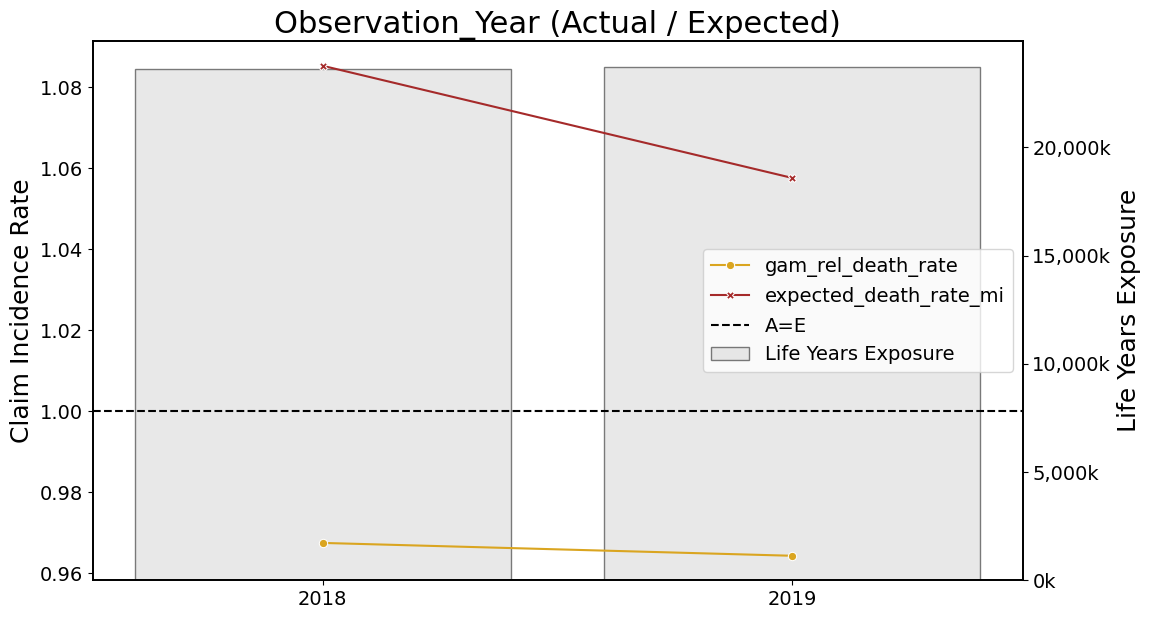

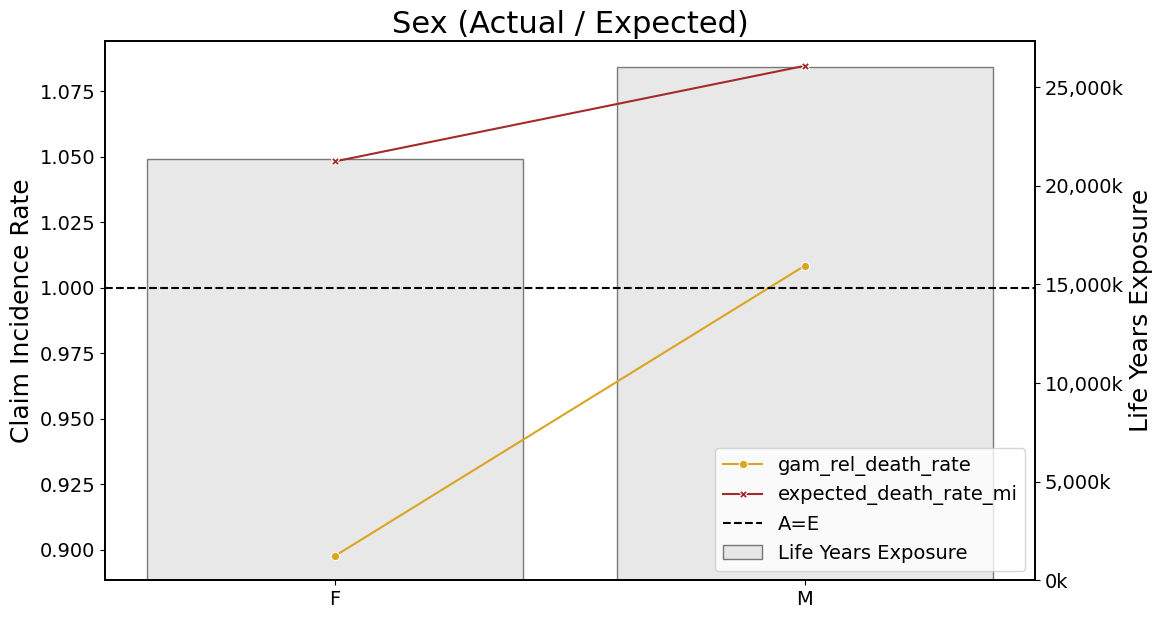

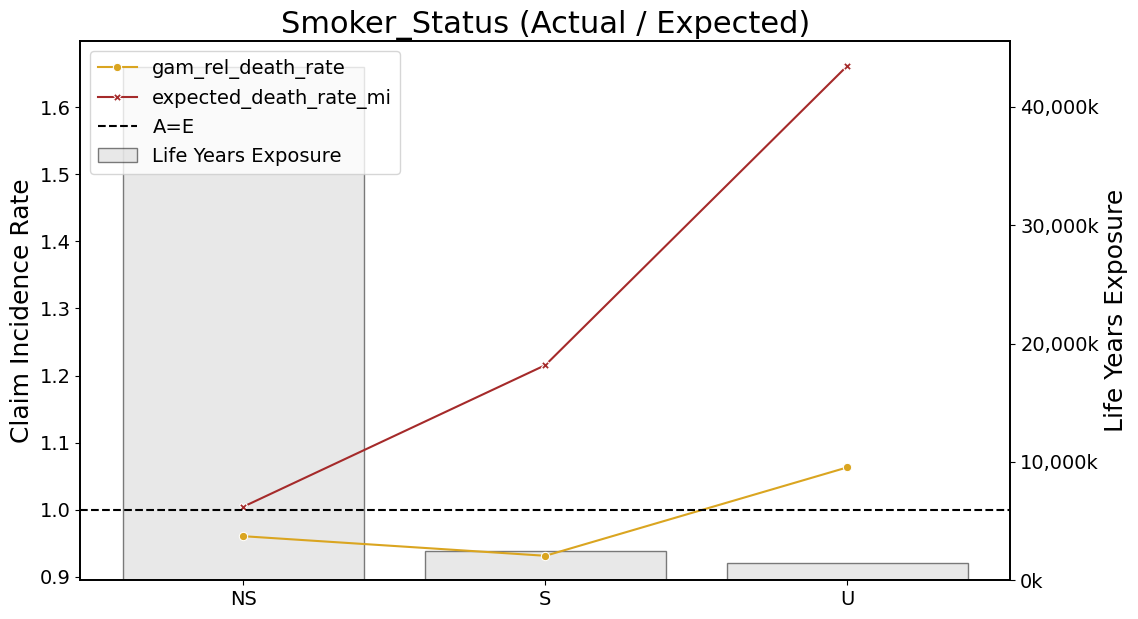

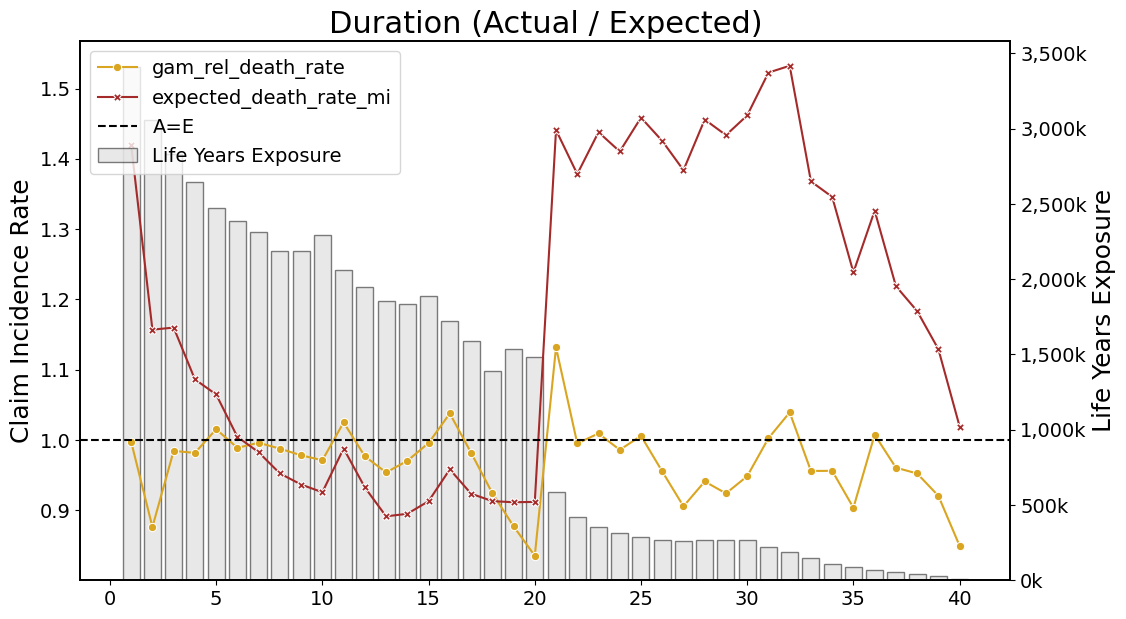

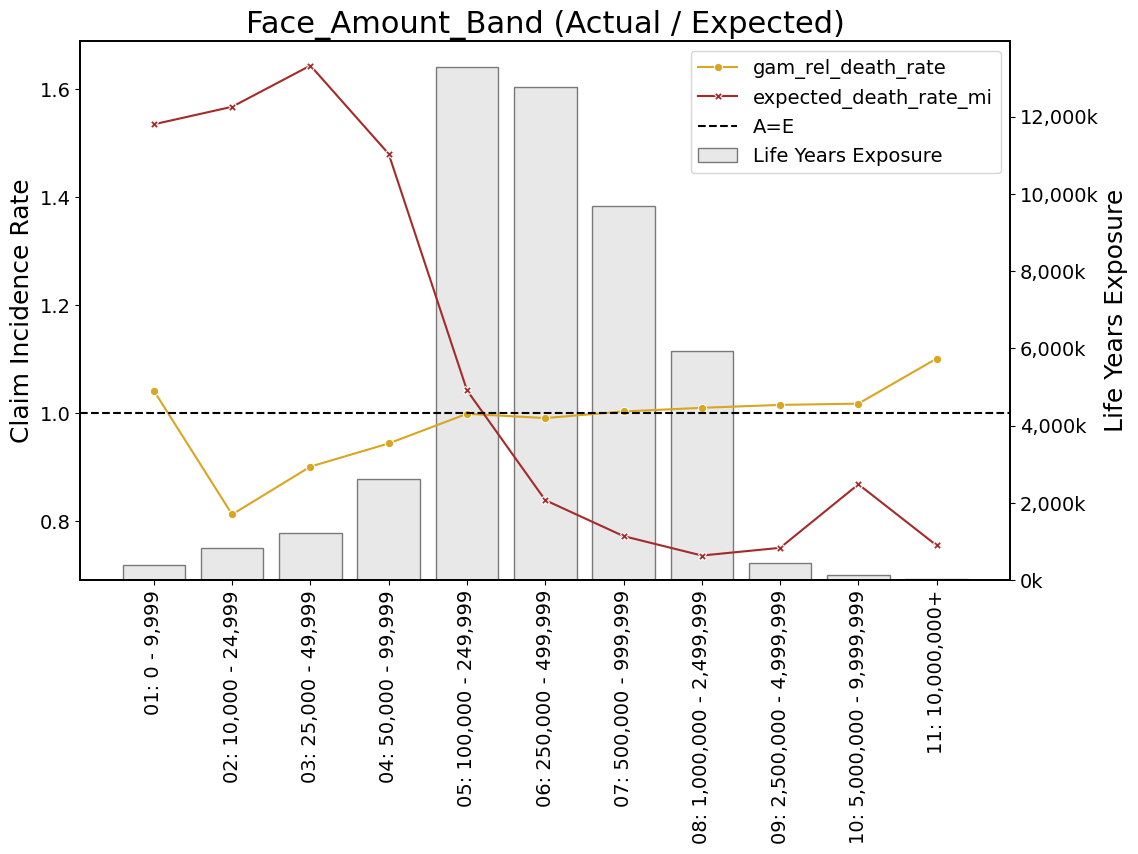

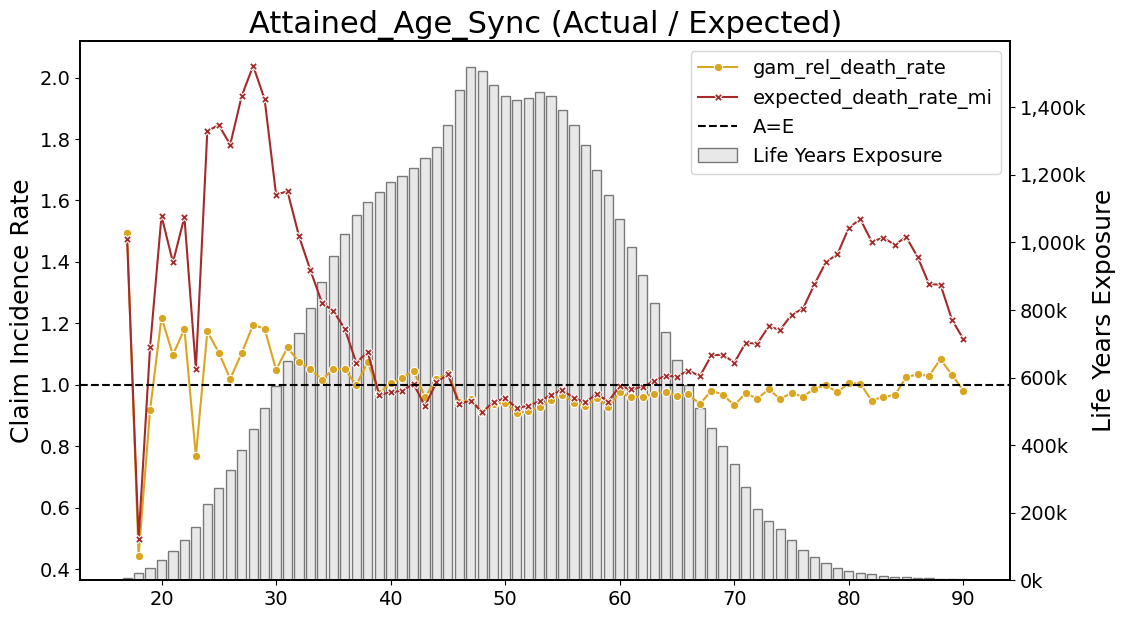

In [74]:
##############################################################################################
##############################################################################################

y1_label = "Claim Incidence Rate"
y2_label = "Life Years Exposure"

##############################################################################################
##############################################################################################

for var in key_features:

    fig, ax = plt.subplots(1, figsize=(12, 7))
    # Plot incidence rates
    sns.lineplot(
        data=risk_agg_dict[var].loc[
            :, ["gam_rel_death_rate", "expected_death_rate_mi"]
        ],
        ax=ax,
        markers=True,
        dashes=False,
        palette=["#DAA520", "#A52A2A"],
    )
    ax.axhline(y=1, color="black", linestyle="--", label="A=E")

    # Set title and x and y axes labels and fontsize
    ax.set_ylabel(y1_label, fontsize=label_fontsize)
    ax.set_xlabel("")
    ax.set_title(var + " (Actual / Expected)", fontsize=title_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

    # Fix the xticker labels if there are decimal places in xtickers when variable should be integers
    if not isinstance(risk_agg_dict[var].index[0], str):
        index_has_decimals = any(val % 1 != 0 for val in risk_agg_dict[var].index)
        ticks_have_decimals = any(tick % 1 != 0 for tick in ax.get_xticks())

        if not index_has_decimals and ticks_have_decimals:
            ax.set_xticks(risk_agg_dict[var].index)
            ax.set_xticklabels(risk_agg_dict[var].index)

    # Format x-axis tickers
    ax.tick_params(
        axis="x",
        rotation=(
            90
            if isinstance(risk_agg_dict[var].index[0], str)
            and len(risk_agg_dict[var].index[0]) > 4
            else 0
        ),
    )

    # Create secondary y-axis for exposures
    ax2 = ax.twinx()
    ax2.bar(
        risk_agg_dict[var].index,
        risk_agg_dict[var][exposure],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=y2_label,
    )

    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=tick_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=tick_fontsize,
        facecolor="white",
    )

    # Set secondary y-axis label
    ax2.set_ylabel(y2_label, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)

## Save down single factor model predictions for interaction detections

In [86]:
# Define a dataframe that contains predictions, target and weight
ypred_train = gam_model.predict(X_train)

ypred_train_df = pd.DataFrame(
    ypred_train, columns=["ypred_death_rate"], index=X_train.index
)
ypred_train_df = (
    ypred_train_df.join(y_train)
    .join(w_train)
    .join(
        model_data[
            [
                "Death_Count",
                "ExpDth_VBT2015_Cnt",
                "ExpDth_VBT2015wMI_Cnt",
                "exp_death_rate",
                "exp_death_rate_mi",
            ]
        ]
    )
)
ypred_train_df["ypred_death_count"] = (
    ypred_train_df["ypred_death_rate"] * ypred_train_df[exposure]
)

# Calculate the death rates and counts from the rating tables
ypred_train_df["ypred_death_rate_rel"] = (
    X_train_rel[rel_list].prod(axis=1) * intercept_final
)
ypred_train_df["ypred_death_count_rel"] = (
    ypred_train_df["ypred_death_rate_rel"] * ypred_train_df[exposure]
)
ypred_train_df["ratio_diff"] = (
    ypred_train_df["ypred_death_count_rel"] / ypred_train_df["ypred_death_count"]
).round(rounding_num)

assert (
    ypred_train_df["ratio_diff"].unique() == 1
), "Differences in predictions from the model and rating tables detected. Please check!!!"
ypred_train_df

,ypred_death_rate,act_death_rate,Policies_Exposed,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,exp_death_rate,exp_death_rate_mi,ypred_death_count,ypred_death_rate_rel,ypred_death_count_rel,ratio_diff
unique_id,,,,,,,,,,,,
0,0.001318,0.000000,85.221704,0.0,0.128005,0.130487,0.001502,0.001531,0.112280,0.001318,0.112280,1.0
1,0.001981,0.000000,16.607149,0.0,0.050614,0.051595,0.003048,0.003107,0.032906,0.001981,0.032906,1.0
2,0.001092,0.001200,6664.746140,8.0,7.494563,7.639922,0.001125,0.001146,7.279165,0.001092,7.279165,1.0
3,0.002625,0.004396,227.479668,1.0,0.341435,0.348057,0.001501,0.001530,0.597216,0.002625,0.597216,1.0
4,0.003775,0.000000,13.977978,0.0,0.024675,0.025154,0.001765,0.001800,0.052774,0.003775,0.052774,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
575748,0.013206,0.000000,0.246575,0.0,0.002900,0.002900,0.011760,0.011760,0.003256,0.013206,0.003256,1.0
575749,0.201562,0.000000,0.304110,0.0,0.038315,0.038315,0.125990,0.125990,0.061297,0.201562,0.061297,1.0
575751,0.015277,0.000000,0.308743,0.0,0.006070,0.006158,0.019660,0.019945,0.004717,0.015277,0.004717,1.0


In [87]:
# Concatenate the training and holdout prediction dataframes 
ypred_df = pd.concat([ypred_train_df, ypred_test_df], axis=0)
ypred_df

,ypred_death_rate,act_death_rate,Policies_Exposed,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,exp_death_rate,exp_death_rate_mi,ypred_death_count,ypred_death_rate_rel,ypred_death_count_rel,ratio_diff
unique_id,,,,,,,,,,,,
0,0.001318,0.000000,85.221704,0.0,0.128005,0.130487,0.001502,0.001531,0.112280,0.001318,0.112280,1.000000
1,0.001981,0.000000,16.607149,0.0,0.050614,0.051595,0.003048,0.003107,0.032906,0.001981,0.032906,1.000000
2,0.001092,0.001200,6664.746140,8.0,7.494563,7.639922,0.001125,0.001146,7.279165,0.001092,7.279165,1.000000
3,0.002625,0.004396,227.479668,1.0,0.341435,0.348057,0.001501,0.001530,0.597216,0.002625,0.597216,1.000000
4,0.003775,0.000000,13.977978,0.0,0.024675,0.025154,0.001765,0.001800,0.052774,0.003775,0.052774,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
575740,0.093225,0.000000,0.221918,0.0,0.010816,0.010611,0.048740,0.047814,0.020688,0.096671,0.021453,1.036973
575744,0.016529,0.000000,0.624658,0.0,0.013411,0.013220,0.021470,0.021163,0.010325,0.016832,0.010514,1.018319
575746,0.007611,0.000000,0.369863,0.0,0.005533,0.005454,0.014960,0.014746,0.002815,0.007751,0.002867,1.018319


In [91]:
###################################################################################
###################################################################################

output_file = "export/Single Factor Model Predictions.parquet"

###################################################################################
###################################################################################

# Export the predictions as a parquet file
ypred_df.to_parquet(output_file)